<a href="https://colab.research.google.com/github/NimrahImran/ML-ALGORITHEMS/blob/main/logistic_regression_loan_pridiction_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. DATA LOADING

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Default_Fin.csv')
display(df.head())

,Index,Employed,Bank Balance,Annual Salary,Defaulted?
0,1,1,8754.36,532339.56,0
1,2,0,9806.16,145273.56,0
2,3,1,12882.60,381205.68,0
3,4,1,6351.00,428453.88,0
4,5,1,9427.92,461562.00,0


In [ ]:
df.shape

(10000, 5)

In [ ]:
df.columns

Index(['Index', 'Employed', 'Bank Balance', 'Annual Salary', 'Defaulted?'], dtype='object')

In [ ]:
df.dtypes

,0
Index,int64
Employed,int64
Bank Balance,float64
Annual Salary,float64
Defaulted?,int64


In [ ]:
df.describe()

,Index,Employed,Bank Balance,Annual Salary,Defaulted?
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,0.705600,10024.498524,402203.782224,0.033300
std,2886.89568,0.455795,5804.579486,160039.674988,0.179428
min,1.00000,0.000000,0.000000,9263.640000,0.000000
25%,2500.75000,0.000000,5780.790000,256085.520000,0.000000
50%,5000.50000,1.000000,9883.620000,414631.740000,0.000000
75%,7500.25000,1.000000,13995.660000,525692.760000,0.000000
max,10000.00000,1.000000,31851.840000,882650.760000,1.000000


## 2. DATA CLEANING

In [ ]:
df.isnull().sum()

,0
Index,0
Employed,0
Bank Balance,0
Annual Salary,0
Defaulted?,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# df.drop_duplicates(inplace=True)

## 3. DATA VISUALIZATION (EDA)

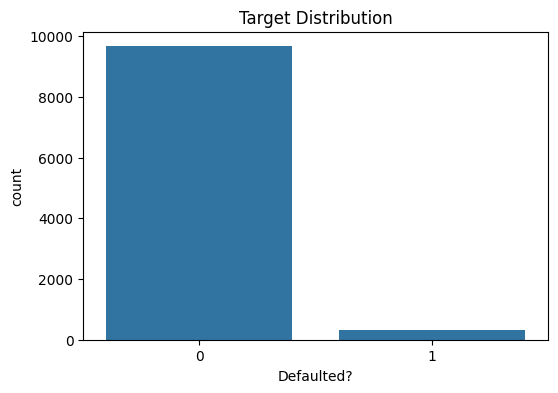

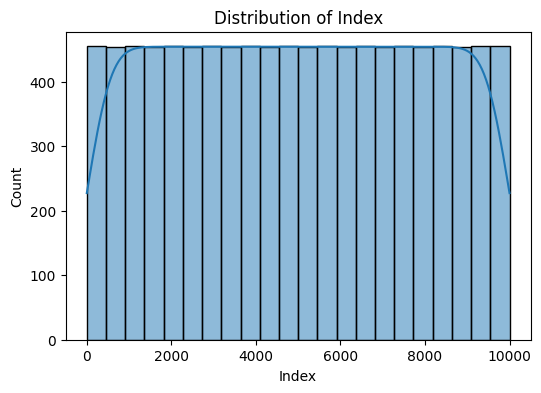

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Target Distribution')
plt.show()

# Plot distribution of a sample feature (e.g., the first numerical feature)
if X.shape[1] > 0:
    plt.figure(figsize=(6, 4))
    sns.histplot(X.iloc[:, 0], kde=True)
    plt.title(f'Distribution of {X.columns[0]}')
    plt.show()

## 4. FEATURE ENGINEERING

In [ ]:
target_column = 'Defaulted?' # Corrected from 'Default'
X = df.drop(columns=[target_column])
y = df[target_column]

# X = pd.get_dummies(X, drop_first=True)
# df.head()

## 5. TRAIN-TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 6. MODEL SELECTION

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Model selected: Logistic Regression

## 7. MODEL TRAINING

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

## 8. MODEL PREDICTION

In [ ]:
y_pred = model.predict(X_test_scaled)

## 9. MODEL EVALUATION

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Confusion Matrix:\n", cm)

Accuracy: 0.9700
F1 Score: 0.3878
Confusion Matrix:
 [[1921   10]
 [  50   19]]


## 10. MODEL TUNING

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1.0, 10.0]}
grid_search = GridSearchCV(LogisticRegression(random_state=42), param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print(f"Best C parameter: {grid_search.best_params_['C']}")

y_pred_tuned = best_model.predict(X_test_scaled)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print(f"Tuned Model Accuracy: {accuracy_tuned:.4f}")
print(f"Tuned Model F1 Score: {f1_tuned:.4f}")

Best C parameter: 10.0
Tuned Model Accuracy: 0.9695
Tuned Model F1 Score: 0.3838


## 11. CROSS VALIDATION

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")

Cross-validation scores: [0.9775   0.97375  0.97375  0.970625 0.9775  ]
Mean CV Accuracy: 0.9746


## 12. PIPELINE BUILDING

In [ ]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, C=grid_search.best_params_['C']))
])

pipe.fit(X_train, y_train)
y_pred_pipe = pipe.predict(X_test)

pipe_accuracy = accuracy_score(y_test, y_pred_pipe)
pipe_f1 = f1_score(y_test, y_pred_pipe)
pipe_cm = confusion_matrix(y_test, y_pred_pipe)

print(f"Pipeline Accuracy: {pipe_accuracy:.4f}")
print(f"Pipeline F1 Score: {pipe_f1:.4f}")
print("Pipeline Confusion Matrix:\n", pipe_cm)

Pipeline Accuracy: 0.9695
Pipeline F1 Score: 0.3838
Pipeline Confusion Matrix:
 [[1920   11]
 [  50   19]]


## 13. MODEL DEPLOYMENT